In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!mkdir -p /content/data/malware
!mkdir -p /content/data/benign


In [5]:
!unzip -o "/content/drive/MyDrive/cyber_fusion_models/MalwareTextDB-1.0 (1).zip" -d /content/data/malware/


Archive:  /content/drive/MyDrive/cyber_fusion_models/MalwareTextDB-1.0 (1).zip
   creating: /content/data/malware/annotation_guidelines/
  inflating: /content/data/malware/annotation_guidelines/AnnotationGuidelines_V2.00.pdf  
  inflating: /content/data/malware/annotation_guidelines/AttributeLabels_V1.01.pdf  
  inflating: /content/data/malware/annotation_guidelines/readme.txt  
   creating: /content/data/malware/data/
  inflating: /content/data/malware/data/.DS_Store  
   creating: /content/data/malware/__MACOSX/
   creating: /content/data/malware/__MACOSX/data/
  inflating: /content/data/malware/__MACOSX/data/._.DS_Store  
   creating: /content/data/malware/data/ann+brown/
  inflating: /content/data/malware/data/ann+brown/AdversaryIntelligenceReport_DeepPanda_0 (1).txtcbn  
  inflating: /content/data/malware/data/ann+brown/Aided_Frame_Aided_Direction.txtcbn  
  inflating: /content/data/malware/data/ann+brown/Alienvault_Scanbox.txtcbn  
  inflating: /content/data/malware/data/ann+brow

In [6]:
!cd /content/data/malware && git clone https://github.com/malware-traffic/indicators malware_traffic


Cloning into 'malware_traffic'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 155 (delta 18), reused 0 (delta 0), pack-reused 120 (from 1)
Receiving objects: 100% (155/155), 77.79 KiB | 2.88 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [7]:
!ls /content/data/malware/malware_traffic | head


2025-02-05-ClearFake-or-ClickFix-fake-CAPTCHA-for-possible-Vidar.txt
2025-02-12-VIP-recovery-infection.txt
2025-02-25-IOCs-for-Venom-RAT-activity.txt
2025-03-05-Astaroth-Guildma-activity-from-Brazil-malspam.txt
2025-03-24-GuLoader-for-Remcos-RAT.txt
2025-04-17-IOCs-for-MassLogger-infection.txt
2025-04-22-IOCs-for-ClickFix-style-campaign-leading-to-StealC-infection.txt
2025-06-27-IOCs-for-SmartApeSG-to-ClickFix-page-to-NetSupport-RAT.txt
2025-07-17-SmartApeSG-for-NetSupport-RAT.txt
2025-07-22-SmartApeSG-URLs.txt


In [8]:
import glob, os

malware_texts = []
malware_labels = []

# ---- MalwareTextDB ----
mt_base = "/content/data/malware/data"
mt_folders = [
    "plaintext",
    "ann-brown",
    "event_chains",
    "signatures",
    "tokenized"
]

for folder in mt_folders:
    path = os.path.join(mt_base, folder)
    if not os.path.exists(path):
        continue

    files = (
        glob.glob(path + "/**/*.txt", recursive=True) +
        glob.glob(path + "/**/*.tokens", recursive=True)
    )

    for f in files:
        try:
            with open(f, "r", encoding="utf-8", errors="ignore") as file:
                text = file.read().replace("\n", " ").strip()
                if len(text) > 150:
                    malware_texts.append(text)
                    malware_labels.append(1)
        except:
            continue

# ---- malware-traffic ----
traffic_dir = "/content/data/malware/malware_traffic"
traffic_files = glob.glob(traffic_dir + "/*.txt")

for f in traffic_files:
    try:
        with open(f, "r", encoding="utf-8", errors="ignore") as file:
            text = file.read().replace("\n", " ").strip()
            if len(text) > 150:
                malware_texts.append(text)
                malware_labels.append(1)
    except:
        continue


def chunk_text(text, chunk_size=800, overlap=100, min_len=300):
    """
    Splits long text into overlapping chunks.
    SAFE for BERT / Transformer models.
    """

    chunks = []
    start = 0
    text_len = len(text)

    while start < text_len:
        end = start + chunk_size
        chunk = text[start:end]

        if len(chunk) >= min_len:
            chunks.append(chunk)

        start += (chunk_size - overlap)

    return chunks


In [9]:
# ================================
# CHUNK MALWARE TEXTS (FINAL)
# ================================

MAX_CHUNKS_PER_DOC = 50   # HARD CAP (VERY IMPORTANT)

chunked_malware_texts = []
chunked_malware_labels = []

for text in malware_texts:
    chunks = chunk_text(text)
    chunks = chunks[:MAX_CHUNKS_PER_DOC]

    chunked_malware_texts.extend(chunks)
    chunked_malware_labels.extend([1] * len(chunks))

print("Original malware reports:", len(malware_texts))
print("Chunked malware samples:", len(chunked_malware_texts))



Original malware reports: 97
Chunked malware samples: 2789


In [10]:
!git clone https://github.com/mitre/cti.git /content/data/benign/mitre_cti


Cloning into '/content/data/benign/mitre_cti'...
remote: Enumerating objects: 625553, done.
remote: Counting objects: 100% (2588/2588), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 625553 (delta 2517), reused 2481 (delta 2479), pack-reused 622965 (from 2)
Receiving objects: 100% (625553/625553), 314.06 MiB | 35.72 MiB/s, done.
Resolving deltas: 100% (611576/611576), done.
Updating files: 100% (34899/34899), done.


In [11]:
import json

mitre_file = "/content/data/benign/mitre_cti/enterprise-attack/enterprise-attack.json"

with open(mitre_file, "r", encoding="utf-8") as f:
    data = json.load(f)

benign_texts = []
benign_labels = []

allowed_types = [
    "attack-pattern",
    "course-of-action",
    "x-mitre-data-source",
    "mitigation"
]

for obj in data["objects"]:
    if obj.get("type") in allowed_types:
        desc = obj.get("description", "")
        if desc and len(desc) > 200:
            benign_texts.append(desc.strip())
            benign_labels.append(0)

print("Original benign documents:", len(benign_texts))
print("Sample benign text:\n", benign_texts[0][:300])


Original benign documents: 1097
Sample benign text:
 Ensure only valid password filters are registered. Filter DLLs must be present in Windows installation directory (<code>C:\Windows\System32\</code> by default) of a domain controller and/or local computer with a corresponding entry in <code>HKEY_LOCAL_MACHINE\SYSTEM\CurrentControlSet\Control\Lsa\Not


In [12]:
# ===============================
# CHUNK BENIGN TEXTS (FINAL)
# ===============================

MAX_CHUNKS_PER_DOC = 50   # MUST MATCH MALWARE

chunked_benign_texts = []
chunked_benign_labels = []

for text in benign_texts:
    chunks = chunk_text(text)
    chunks = chunks[:MAX_CHUNKS_PER_DOC]   # HARD CAP

    chunked_benign_texts.extend(chunks)
    chunked_benign_labels.extend([0] * len(chunks))

print("Original benign documents:", len(benign_texts))
print("Chunked benign samples:", len(chunked_benign_texts))


Original benign documents: 1097
Chunked benign samples: 2037


In [13]:
# ===============================
# BALANCE CLASSES (FINAL)
# ===============================

max_malware = len(chunked_malware_texts)

if len(chunked_benign_texts) > max_malware:
    chunked_benign_texts = chunked_benign_texts[:max_malware]
    chunked_benign_labels = chunked_benign_labels[:max_malware]

print("Malware chunks:", len(chunked_malware_texts))
print("Benign chunks :", len(chunked_benign_texts))


Malware chunks: 2789
Benign chunks : 2037


In [14]:
# ===============================
# COMBINE DATASETS
# ===============================

texts  = chunked_malware_texts + chunked_benign_texts
labels = chunked_malware_labels + chunked_benign_labels

print("Total samples:", len(texts))
print("Total labels :", len(labels))


Total samples: 4826
Total labels : 4826


In [15]:
from sklearn.utils import shuffle

texts, labels = shuffle(texts, labels, random_state=42)


In [16]:
# ================================
# Train / Test split
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.30,        # 70% train, 30% test
    random_state=42,
    stratify=labels
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# Label distribution check
print("\nTrain malware:", sum(y_train), "benign:", len(y_train) - sum(y_train))
print("Test malware:", sum(y_test), "benign:", len(y_test) - sum(y_test))


Train size: 3378
Test size: 1448

Train malware: 1952 benign: 1426
Test malware: 837 benign: 611


In [17]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 256 # standard for BERT

def tokenize_texts(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

# Tokenize splits
train_encodings = tokenize_texts(X_train)
test_encodings  = tokenize_texts(X_test)

print("Tokenization done.")
print("Train input_ids shape:", train_encodings["input_ids"].shape)
print("Test input_ids shape:", test_encodings["input_ids"].shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenization done.
Train input_ids shape: torch.Size([3378, 256])
Test input_ids shape: torch.Size([1448, 256])


In [18]:
# Step 1:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertForSequenceClassification
from torch.optim import AdamW


In [19]:
#Step 2: Create a Dataset class (required by PyTorch)
# This just wraps your tokenized data so BERT can train on it.

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


In [20]:
#Step 3: Create Train & Validation datasets
train_dataset = TextDataset(train_encodings, y_train)
test_dataset  = TextDataset(test_encodings, y_test)


In [21]:
#Step 4: Create DataLoaders

# ================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [22]:
#Step 5: Load pretrained BERT classifier
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.3, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [23]:
# Define optimizer
optimizer = AdamW(model.parameters(), lr=1e-5)

In [24]:
# Train the model
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_train_loss:.4f}")


Epoch 1/3 - Train Loss: 0.1099
Epoch 2/3 - Train Loss: 0.0138
Epoch 3/3 - Train Loss: 0.0042


In [25]:
# STEP: Test DataLoader

test_dataset = TextDataset(test_encodings, y_test)
test_loader = DataLoader(test_dataset, batch_size=8)


In [26]:
import torch
import numpy as np

model.eval()

all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)        # probabilities
        preds = torch.argmax(probs, dim=1)           # predicted class

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy()) # malware probability

print("Test inference completed.")


Test inference completed.


===== TEXT BRANCH EVALUATION =====
Accuracy  : 0.9703
Precision : 1.0000
Recall    : 0.9486
F1-score  : 0.9736
ROC-AUC   : 0.9998


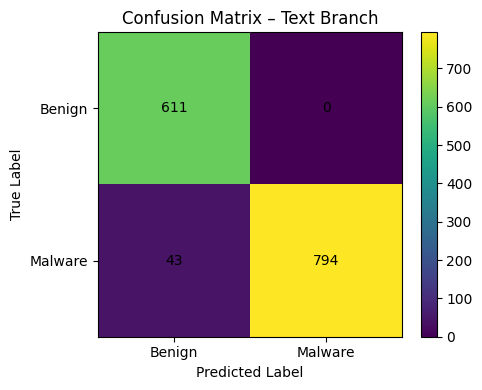

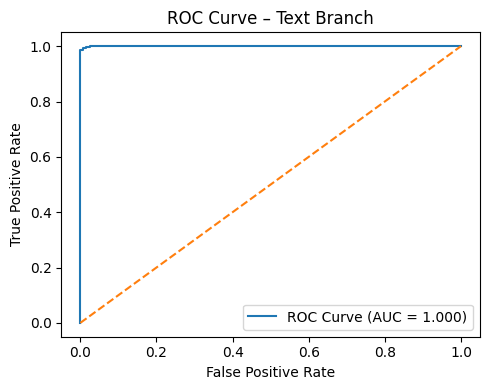

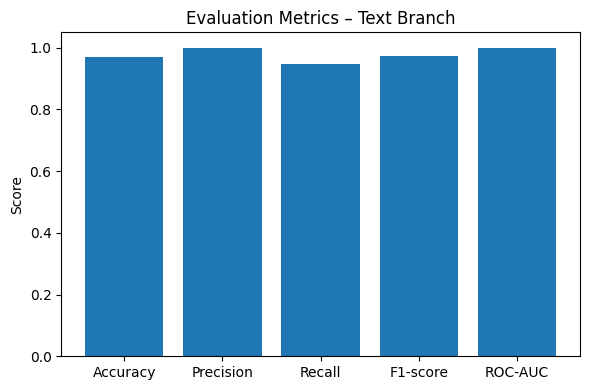

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# ===============================
# METRIC COMPUTATION
# ===============================
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels, all_preds, zero_division=0)
f1   = f1_score(all_labels, all_preds, zero_division=0)
auc  = roc_auc_score(all_labels, all_probs)

print("===== TEXT BRANCH EVALUATION =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ===============================
# CONFUSION MATRIX PLOT
# ===============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix – Text Branch")
plt.colorbar()

plt.xticks([0,1], ["Benign", "Malware"])
plt.yticks([0,1], ["Benign", "Malware"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ===============================
# ROC CURVE PLOT
# ===============================
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Text Branch")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ===============================
# METRIC BAR CHART (OPTIONAL)
# ===============================
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
values  = [acc, prec, rec, f1, auc]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylim(0, 1.05)
plt.title("Evaluation Metrics – Text Branch")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

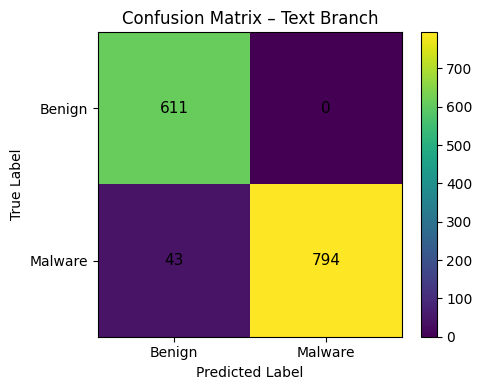

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix – Text Branch")
plt.colorbar()

class_names = ["Benign", "Malware"]
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black", fontsize=11)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [29]:
import numpy as np
import os

os.makedirs("fusion_outputs", exist_ok=True)

np.save("fusion_outputs/text_labels.npy", np.array(all_labels))
np.save("fusion_outputs/text_preds.npy", np.array(all_preds))
np.save("fusion_outputs/text_probs.npy", np.array(all_probs))

print("Text branch outputs saved for fusion.")


Text branch outputs saved for fusion.


In [31]:
import pandas as pd
import numpy as np

probs  = np.load("fusion_outputs/text_probs.npy")
preds  = np.load("fusion_outputs/text_preds.npy")
labels = np.load("fusion_outputs/text_labels.npy")

text_df = pd.DataFrame({
    "text_prob": probs,
    "text_pred": preds,
    "label": labels
})

text_df.to_csv("fusion_outputs/text_results.csv", index=False)


In [32]:
!cp fusion_outputs/text_results.csv /content/drive/MyDrive/cyber_fusion_models/results/
